In [2]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim

import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [3]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [8]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DATA_DIR = Path("/kaggle/working/SplitDATA") / "data"
DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
MODEL_NAME_BASELINE = "deit_small_patch16_224"

TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 1e-4
ALPHA = 0.3
TAU = 2.0
# LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
# ALPHA = 0.5
# TAU = 1.0
PATIENCE = 5


In [ ]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")

#imbalance cls
# class_counts = Counter(train_dataset.labels)
# print("Class counts:", class_counts)

# from sklearn.utils.class_weight import compute_class_weight
# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.arange(5),
#     y=train_dataset.labels
# )
# class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

# print("Class weights:", class_weights)


class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)


class_weights = None

print("Class weights disabled to prevent severe-class overprediction.")


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21074 images
Val dataset:   7026 images
Test dataset:  7026 images
Class counts: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Class weights disabled to prevent severe-class overprediction.

Data loaders ready!


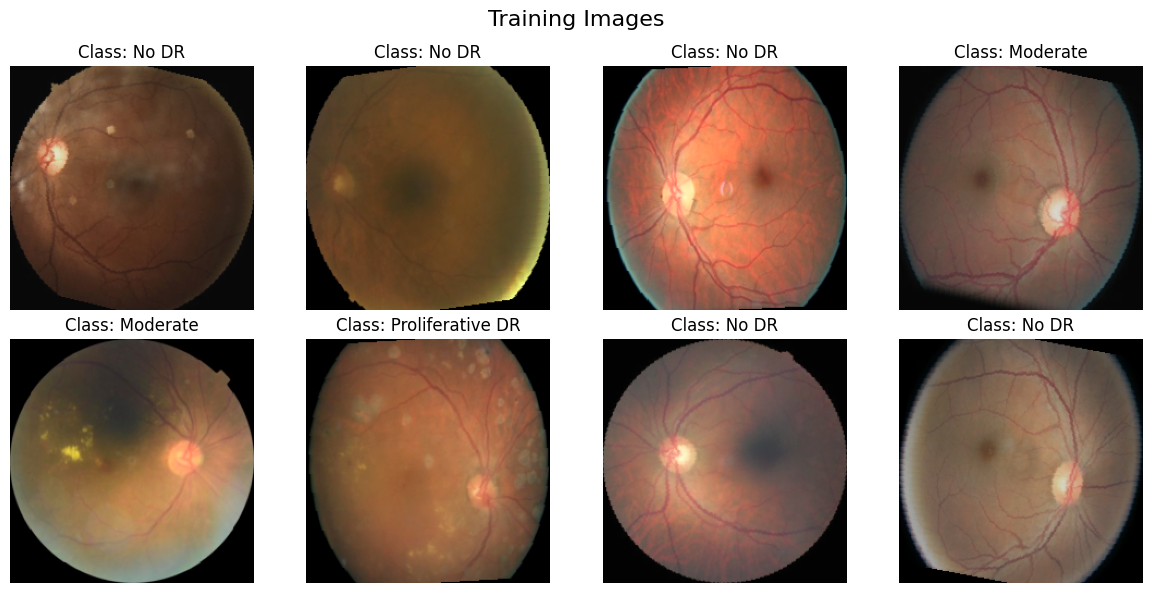

In [10]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [11]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

Student model: deit_small_distilled_patch16_224
Total params: 21.67M
Trainable params: 21.67M


In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, cohen_kappa_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"
teacher_log_path = "SplitDATA/logs/teacher_training_log.txt"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    criterion_teacher = nn.CrossEntropyLoss(
        #weight=class_weights,
        label_smoothing=0.05
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val_qwk = -1.0
    best_val_f1 = -1.0

    with open(teacher_log_path, "w") as f:
        f.write("====================================================\n")
        f.write("Teacher Training Log - RegNetY-160\n")
        f.write("====================================================\n\n")

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader, desc=f"Teacher Train {epoch+1}/{epochs}", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer_teacher)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer_teacher)
            scaler.update()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="macro")

        model.eval()

        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc=f"Teacher Val {epoch+1}/{epochs}", leave=False):

                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(val_labels, val_preds)
        val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")
        val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

        scheduler_teacher.step()

        epoch_log = (
            f"\n====================================================\n"
            f"Teacher Epoch {epoch+1}/{epochs}\n"
            f"====================================================\n"
            f"Train Loss          : {train_loss:.4f}\n"
            f"Train Accuracy      : {train_acc*100:.2f}%\n"
            f"Train Macro-F1      : {train_f1:.4f}\n\n"
            f"Val Loss            : {val_loss:.4f}\n"
            f"Val Accuracy        : {val_acc*100:.2f}%\n"
            f"Val Balanced Acc    : {val_bal_acc:.4f}\n"
            f"Val Macro-F1        : {val_f1:.4f}\n"
            f"Val QWK             : {val_qwk:.4f}\n"
        )

        print(epoch_log)

        with open(teacher_log_path, "a") as f:
            f.write(epoch_log)

        if val_qwk > best_val_qwk:

            best_val_qwk = val_qwk
            best_val_f1 = val_f1

            torch.save(model.state_dict(), ckpt_path)

            msg = (
                f"\nBest teacher saved\n"
                f"Best Val QWK      : {best_val_qwk:.4f}\n"
                f"Val Macro-F1      : {best_val_f1:.4f}\n"
            )

            print(msg)

            with open(teacher_log_path, "a") as f:
                f.write(msg)

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    final_msg = (
        f"\nTeacher ready\n"
        f"Best Val QWK      : {best_val_qwk:.4f}\n"
        f"Best Val Macro-F1 : {best_val_f1:.4f}\n"
    )

    print(final_msg)

    with open(teacher_log_path, "a") as f:
        f.write(final_msg)

    return model

teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Teacher loaded and frozen for distillation.")


Teacher Epoch 1/12
Train Loss          : 0.9162
Train Accuracy      : 73.01%
Train Macro-F1      : 0.2245

Val Loss            : 0.9002
Val Accuracy        : 75.49%
Val Balanced Acc    : 0.2635
Val Macro-F1        : 0.2793
Val QWK             : 0.2785


Best teacher saved
Best Val QWK      : 0.2785
Val Macro-F1      : 0.2793




Teacher Epoch 2/12
Train Loss          : 0.8148
Train Accuracy      : 76.54%
Train Macro-F1      : 0.3502

Val Loss            : 0.8247
Val Accuracy        : 76.50%
Val Balanced Acc    : 0.3040
Val Macro-F1        : 0.3288
Val QWK             : 0.4463


Best teacher saved
Best Val QWK      : 0.4463
Val Macro-F1      : 0.3288




Teacher Epoch 3/12
Train Loss          : 0.7805
Train Accuracy      : 78.07%
Train Macro-F1      : 0.3932

Val Loss            : 0.7930
Val Accuracy        : 77.23%
Val Balanced Acc    : 0.4561
Val Macro-F1        : 0.4347
Val QWK             : 0.5811


Best teacher saved
Best Val QWK      : 0.5811
Val Macro-F1      : 0.4347




Teacher Epoch 4/12
Train Loss          : 0.7600
Train Accuracy      : 78.75%
Train Macro-F1      : 0.4176

Val Loss            : 0.7724
Val Accuracy        : 78.66%
Val Balanced Acc    : 0.3749
Val Macro-F1        : 0.4193
Val QWK             : 0.5357




Teacher Epoch 5/12
Train Loss          : 0.7340
Train Accuracy      : 79.90%
Train Macro-F1      : 0.4484

Val Loss            : 0.7666
Val Accuracy        : 78.66%
Val Balanced Acc    : 0.4039
Val Macro-F1        : 0.4382
Val QWK             : 0.5644



...


Teacher Epoch 9/12
Train Loss          : 0.6309
Train Accuracy      : 83.60%
Train Macro-F1      : 0.5409

Val Loss            : 0.7045
Val Accuracy        : 81.67%
Val Balanced Acc    : 0.4774
Val Macro-F1        : 0.5051
Val QWK             : 0.6907


Best teacher saved
Best Val QWK      : 0.6907
Val Macro-F1      : 0.5051




Teacher Epoch 10/12
Train Loss          : 0.6024
Train Accuracy      : 84.78%
Train Macro-F1      : 0.5812

Val Loss            : 0.7105
Val Accuracy        : 81.68%
Val Balanced Acc    : 0.5011
Val Macro-F1        : 0.5326
Val QWK             : 0.7112


Best teacher saved
Best Val QWK      : 0.7112
Val Macro-F1      : 0.5326




Teacher Epoch 11/12
Train Loss          : 0.5775
Train Accuracy      : 85.65%
Train Macro-F1      : 0.6182

Val Loss            : 0.7213
Val Accuracy        : 81.84%
Val Balanced Acc    : 0.4765
Val Macro-F1        : 0.5162
Val QWK             : 0.7039



/tmp/ipykernel_402308/681341331.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))



Teacher Epoch 12/12
Train Loss          : 0.5596
Train Accuracy      : 86.42%
Train Macro-F1      : 0.6355

Val Loss            : 0.7236
Val Accuracy        : 81.71%
Val Balanced Acc    : 0.4917
Val Macro-F1        : 0.5268
Val QWK             : 0.7075


Teacher ready
Best Val QWK      : 0.7112
Best Val Macro-F1 : 0.5326

Teacher loaded and frozen for distillation.


In [13]:

import torch.optim as optim
# Distillation training setup
criterion_cls = nn.CrossEntropyLoss(
    #weight=class_weights,
    label_smoothing=0.05
)

# KL divergence for soft distillation
criterion_dist = nn.KLDivLoss(reduction="batchmean")

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"ALPHA = {ALPHA}, TAU = {TAU}")

ALPHA = 0.3, TAU = 2.0


In [ ]:

# DeiT WITHOUT DISTILLATION token / Uses normal DeiT, no teacher

baseline_model = timm.create_model(
    MODEL_NAME_BASELINE,
    pretrained=True,
    num_classes=5
).to(DEVICE)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=NUM_EPOCHS
)

baseline_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

best_baseline_qwk = -1.0
baseline_patience_counter = 0

baseline_log_path = "SplitDATA/logs/deit_without_distillation_log.txt"

with open(baseline_log_path, "w") as f:
    f.write("=====================================================\n")
    f.write("DeiT WITHOUT Distillation Training Log\n")
    f.write("=====================================================\n\n")
    f.write(f"Model: {MODEL_NAME_BASELINE}\n")
    f.write("Teacher Used: No\n")
    f.write("Loss: CrossEntropy only\n\n")

for epoch in range(1, NUM_EPOCHS + 1):

    baseline_model.train()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"No-Distill Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

        baseline_scaler.scale(loss).backward()

        baseline_scaler.unscale_(baseline_optimizer)
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), max_norm=1.0)

        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
        # baseline_scaler.step(baseline_optimizer)
        # baseline_scaler.update()

        train_loss += loss.item()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")


    baseline_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"No-Distill Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    baseline_scheduler.step()

    epoch_log = (
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"Train Loss          : {train_loss:.4f}\n"
        f"Train Accuracy      : {train_acc*100:.2f}%\n"
        f"Train Macro-F1      : {train_f1:.4f}\n"
        f"Validation Loss     : {val_loss:.4f}\n"
        f"Validation Accuracy : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc  : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1 : {val_f1:.4f}\n"
        f"Validation QWK      : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(baseline_log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_baseline_qwk:

        best_baseline_qwk = val_qwk
        baseline_patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "SplitDATA/checkpoints/best_deit_without_distillation.pth"
        )

        msg = f"\nBest no-distillation DeiT saved | Val QWK: {val_qwk:.4f}\n"
        print(msg)

        with open(baseline_log_path, "a") as f:
            f.write(msg)

    else:

        baseline_patience_counter += 1

        if baseline_patience_counter >= PATIENCE:
            stop_msg = f"\nEarly stopping at epoch {epoch}\n"
            print(stop_msg)

            with open(baseline_log_path, "a") as f:
                f.write(stop_msg)

            break

print(f"DeiT without distillation complete | Best Val QWK: {best_baseline_qwk:.4f}")


Epoch 01/12
Train Loss          : 0.8828
Train Accuracy      : 74.73%
Train Macro-F1      : 0.2839
Validation Loss     : 0.8541
Validation Accuracy : 75.43%
Validation Bal Acc  : 0.2943
Validation Macro-F1 : 0.3210
Validation QWK      : 0.3484


Best no-distillation DeiT saved | Val QWK: 0.3484




Epoch 02/12
Train Loss          : 0.8277
Train Accuracy      : 76.35%
Train Macro-F1      : 0.3595
Validation Loss     : 0.8251
Validation Accuracy : 76.26%
Validation Bal Acc  : 0.3673
Validation Macro-F1 : 0.4007
Validation QWK      : 0.4580


Best no-distillation DeiT saved | Val QWK: 0.4580




Epoch 03/12
Train Loss          : 0.7961
Train Accuracy      : 77.32%
Train Macro-F1      : 0.4033
Validation Loss     : 0.8312
Validation Accuracy : 76.26%
Validation Bal Acc  : 0.3256
Validation Macro-F1 : 0.3651
Validation QWK      : 0.3831




Epoch 04/12
Train Loss          : 0.7738
Train Accuracy      : 78.10%
Train Macro-F1      : 0.4305
Validation Loss     : 0.7888
Validation Accuracy : 77.60%
Validation Bal Acc  : 0.3635
Validation Macro-F1 : 0.4055
Validation QWK      : 0.5105


Best no-distillation DeiT saved | Val QWK: 0.5105




Epoch 05/12
Train Loss          : 0.7434
Train Accuracy      : 79.19%
Train Macro-F1      : 0.4719
Validation Loss     : 0.8007
Validation Accuracy : 78.11%
Validation Bal Acc  : 0.3980
Validation Macro-F1 : 0.4326
Validation QWK      : 0.5498


Best no-distillation DeiT saved | Val QWK: 0.5498



...


Epoch 08/12
Train Loss          : 0.6257
Train Accuracy      : 83.53%
Train Macro-F1      : 0.6061
Validation Loss     : 0.8032
Validation Accuracy : 78.68%
Validation Bal Acc  : 0.4402
Validation Macro-F1 : 0.4717
Validation QWK      : 0.6141


Best no-distillation DeiT saved | Val QWK: 0.6141




Epoch 09/12
Train Loss          : 0.5732
Train Accuracy      : 85.62%
Train Macro-F1      : 0.6814
Validation Loss     : 0.8240
Validation Accuracy : 77.92%
Validation Bal Acc  : 0.4215
Validation Macro-F1 : 0.4575
Validation QWK      : 0.5938




Epoch 10/12
Train Loss          : 0.5176
Train Accuracy      : 87.85%
Train Macro-F1      : 0.7475
Validation Loss     : 0.8627
Validation Accuracy : 78.37%
Validation Bal Acc  : 0.4219
Validation Macro-F1 : 0.4622
Validation QWK      : 0.5972




Epoch 11/12
Train Loss          : 0.4752
Train Accuracy      : 89.84%
Train Macro-F1      : 0.7980
Validation Loss     : 0.8794
Validation Accuracy : 76.09%
Validation Bal Acc  : 0.4437
Validation Macro-F1 : 0.4712
Validation QWK      : 0.6003




Epoch 12/12
Train Loss          : 0.4531
Train Accuracy      : 90.76%
Train Macro-F1      : 0.8223
Validation Loss     : 0.8800
Validation Accuracy : 76.97%
Validation Bal Acc  : 0.4371
Validation Macro-F1 : 0.4718
Validation QWK      : 0.6037

DeiT without distillation complete | Best Val QWK: 0.6141


In [ ]:
# Full DeiT distillation training

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score
)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("=========================================================\n")
    f.write("Diabetic Retinopathy DeiT Distillation Training Log\n")
    f.write("=========================================================\n\n")

    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Image Size: {IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Patience: {PATIENCE}\n")
    f.write(f"Temperature TAU: {TAU}\n")
    f.write(f"Distillation Alpha: {ALPHA}\n\n")

    f.write("=========================================================\n")
    f.write("EPOCH RESULTS\n")
    f.write("=========================================================\n")

best_val_qwk = -1.0
best_val_f1 = -1.0
patience_counter = 0

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_qwk": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            teacher_logits = teacher_model(images)

    
        with torch.amp.autocast("cuda", enabled=use_amp):

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

   

    student_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_qwk = cohen_kappa_score(
        val_labels,
        val_preds,
        weights="quadratic"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    epoch_log = (
        f"\n=========================================================\n"
        f"Epoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"=========================================================\n"
        f"Train Loss           : {train_loss:.4f}\n"
        f"Train Accuracy       : {train_acc*100:.2f}%\n"
        f"Train Macro-F1       : {train_f1:.4f}\n\n"
        f"Validation Loss      : {val_loss:.4f}\n"
        f"Validation Accuracy  : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc   : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1  : {val_f1:.4f}\n"
        f"Validation QWK       : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_val_qwk:

        best_val_qwk = val_qwk
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            student_model.state_dict(),
            "SplitDATA/checkpoints/best_distilled_deit_model.pth"
        )

        best_msg = (
            f"\nBEST MODEL SAVED\n"
            f"Validation QWK      : {val_qwk:.4f}\n"
            f"Validation Macro-F1 : {val_f1:.4f}\n"
        )

        print(best_msg)

        with open(log_path, "a") as f:
            f.write(best_msg)

    else:

        patience_counter += 1

        patience_msg = (
            f"\nNo QWK improvement. "
            f"Patience Counter: {patience_counter}/{PATIENCE}\n"
        )

        print(patience_msg)

        with open(log_path, "a") as f:
            f.write(patience_msg)

        if patience_counter >= PATIENCE:

            stop_msg = f"\nEarly stopping at epoch {epoch}\n"

            print(stop_msg)

            with open(log_path, "a") as f:
                f.write(stop_msg)

            break

final_summary = (
    f"\n=========================================================\n"
    f"TRAINING COMPLETE\n"
    f"=========================================================\n"
    f"Best Validation QWK      : {best_val_qwk:.4f}\n"
    f"Best Validation Macro-F1 : {best_val_f1:.4f}\n"
)

print(final_summary)

with open(log_path, "a") as f:
    f.write(final_summary)


Epoch 01/12
Train Loss           : 0.7290
Train Accuracy       : 75.08%
Train Macro-F1       : 0.3104

Validation Loss      : 0.6885
Validation Accuracy  : 75.92%
Validation Bal Acc   : 0.2851
Validation Macro-F1  : 0.3122
Validation QWK       : 0.3504


BEST MODEL SAVED
Validation QWK      : 0.3504
Validation Macro-F1 : 0.3122




Epoch 02/12
Train Loss           : 0.6605
Train Accuracy       : 76.93%
Train Macro-F1       : 0.3876

Validation Loss      : 0.6623
Validation Accuracy  : 76.89%
Validation Bal Acc   : 0.3392
Validation Macro-F1  : 0.3812
Validation QWK       : 0.4492


BEST MODEL SAVED
Validation QWK      : 0.4492
Validation Macro-F1 : 0.3812




Epoch 03/12
Train Loss           : 0.6348
Train Accuracy       : 77.79%
Train Macro-F1       : 0.4222

Validation Loss      : 0.6445
Validation Accuracy  : 77.47%
Validation Bal Acc   : 0.3696
Validation Macro-F1  : 0.4113
Validation QWK       : 0.4662


BEST MODEL SAVED
Validation QWK      : 0.4662
Validation Macro-F1 : 0.4113




Epoch 04/12
Train Loss           : 0.6065
Train Accuracy       : 78.60%
Train Macro-F1       : 0.4568

Validation Loss      : 0.6155
Validation Accuracy  : 78.25%
Validation Bal Acc   : 0.4216
Validation Macro-F1  : 0.4508
Validation QWK       : 0.5619


BEST MODEL SAVED
Validation QWK      : 0.5619
Validation Macro-F1 : 0.4508




Epoch 05/12
Train Loss           : 0.5831
Train Accuracy       : 79.39%
Train Macro-F1       : 0.4755

Validation Loss      : 0.6094
Validation Accuracy  : 78.66%
Validation Bal Acc   : 0.4151
Validation Macro-F1  : 0.4528
Validation QWK       : 0.5732


BEST MODEL SAVED
Validation QWK      : 0.5732
Validation Macro-F1 : 0.4528



...


Epoch 08/12
Train Loss           : 0.5066
Train Accuracy       : 82.85%
Train Macro-F1       : 0.5757

Validation Loss      : 0.5983
Validation Accuracy  : 78.79%
Validation Bal Acc   : 0.4538
Validation Macro-F1  : 0.4796
Validation QWK       : 0.6247


BEST MODEL SAVED
Validation QWK      : 0.6247
Validation Macro-F1 : 0.4796




Epoch 09/12
Train Loss           : 0.4788
Train Accuracy       : 84.24%
Train Macro-F1       : 0.6220

Validation Loss      : 0.5948
Validation Accuracy  : 79.35%
Validation Bal Acc   : 0.4298
Validation Macro-F1  : 0.4787
Validation QWK       : 0.6152


No QWK improvement. Patience Counter: 1/5




Epoch 10/12
Train Loss           : 0.4544
Train Accuracy       : 85.67%
Train Macro-F1       : 0.6496

Validation Loss      : 0.5973
Validation Accuracy  : 79.39%
Validation Bal Acc   : 0.4615
Validation Macro-F1  : 0.4932
Validation QWK       : 0.6443


BEST MODEL SAVED
Validation QWK      : 0.6443
Validation Macro-F1 : 0.4932




Epoch 11/12
Train Loss           : 0.4336
Train Accuracy       : 86.69%
Train Macro-F1       : 0.6803

Validation Loss      : 0.5968
Validation Accuracy  : 79.05%
Validation Bal Acc   : 0.4526
Validation Macro-F1  : 0.4872
Validation QWK       : 0.6396


No QWK improvement. Patience Counter: 1/5




Epoch 12/12
Train Loss           : 0.4255
Train Accuracy       : 87.19%
Train Macro-F1       : 0.6933

Validation Loss      : 0.6009
Validation Accuracy  : 79.19%
Validation Bal Acc   : 0.4534
Validation Macro-F1  : 0.4904
Validation QWK       : 0.6456


BEST MODEL SAVED
Validation QWK      : 0.6456
Validation Macro-F1 : 0.4904


TRAINING COMPLETE
Best Validation QWK      : 0.6456
Best Validation Macro-F1 : 0.4904



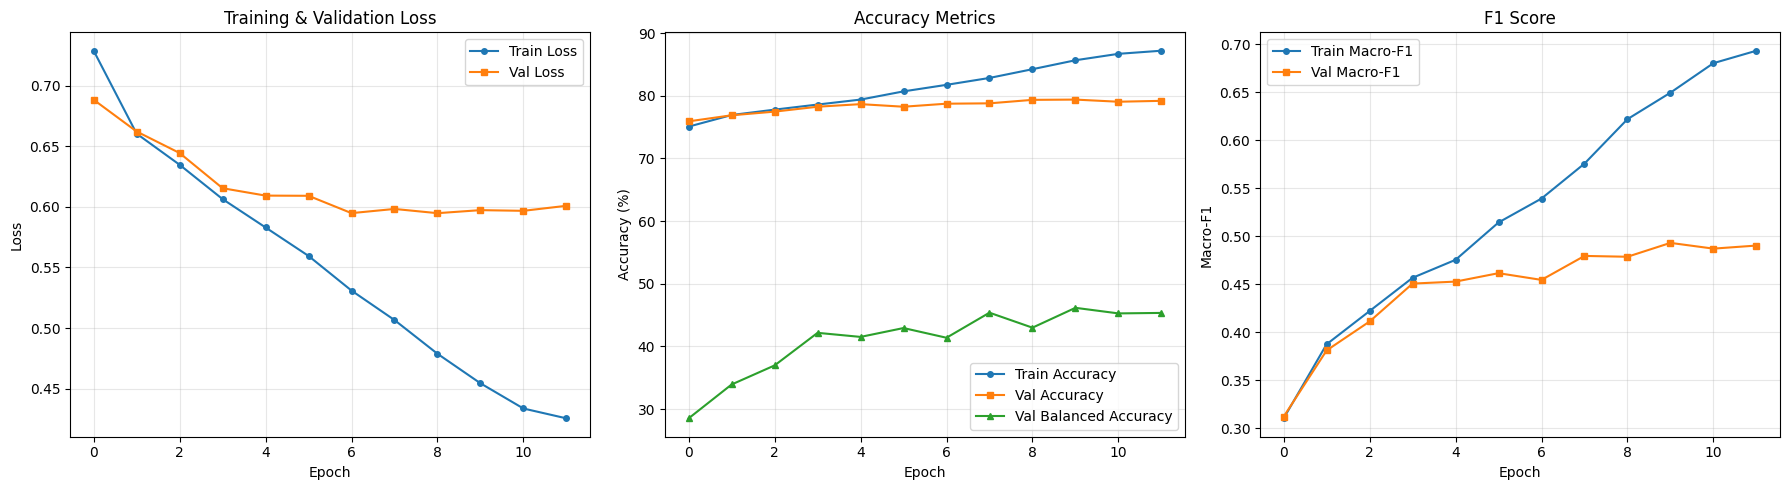

In [16]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [ ]:
from collections import Counter
import os

print("Train labels:", Counter(train_dataset.labels))
print("Val labels:  ", Counter(val_dataset.labels))
print("Test labels: ", Counter(test_dataset.labels))

print("\nCheckpoint exists?")
print("Without distillation:", os.path.exists("SplitDATA/checkpoints/best_deit_without_distillation.pth"))
print("With distillation:   ", os.path.exists("SplitDATA/checkpoints/best_distilled_deit_model.pth"))
print("Teacher:             ", os.path.exists("SplitDATA/checkpoints/teacher_regnety160_best.pth"))

Train labels: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Val labels:   Counter({0: 5165, 2: 1050, 1: 495, 3: 178, 4: 138})
Test labels:  Counter({0: 5154, 2: 1058, 1: 493, 3: 172, 4: 149})

Checkpoint exists?
Without distillation: True
With distillation:    True
Teacher:              True


In [ ]:

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs("SplitDATA/logs", exist_ok=True)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs


def evaluate_and_save_test_results(
    model,
    test_loader,
    model_name,
    checkpoint_path,
    save_path,
    is_distilled=False
):
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    test_preds = []
    test_labels = []
    test_probs = []

    print(f"\nTesting: {model_name}")

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)
            preds = final_logits.argmax(dim=1)

            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_probs = np.array(test_probs)
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    cm = confusion_matrix(test_labels, test_preds)

    test_acc = accuracy_score(test_labels, test_preds)
    test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
    macro_precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
    mcc = matthews_corrcoef(test_labels, test_preds)

    try:
        multiclass_auc = roc_auc_score(
            test_labels,
            test_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        multiclass_auc = None

    report = classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    result_text = (
        f"====================================================\n"
        f"TEST RESULTS - {model_name}\n"
        f"====================================================\n\n"
        f"Checkpoint                : {checkpoint_path}\n\n"
        f"Accuracy                  : {test_acc:.4f}\n"
        f"Balanced Accuracy         : {test_bal_acc:.4f}\n"
        f"Macro Precision           : {macro_precision:.4f}\n"
        f"Macro Recall              : {macro_recall:.4f}\n"
        f"Macro F1                  : {macro_f1:.4f}\n"
        f"Weighted F1               : {weighted_f1:.4f}\n"
        f"Quadratic Weighted Kappa  : {qwk:.4f}\n"
        f"Matthews Corrcoef         : {mcc:.4f}\n"
        f"Macro ROC-AUC OvR         : {multiclass_auc if multiclass_auc is not None else 'Not available'}\n\n"
        f"Classification Report:\n"
        f"{report}\n\n"
        f"Confusion Matrix:\n"
        f"{cm}\n\n"
        f"Class-wise Sensitivity / Specificity:\n"
    )

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        result_text += (
            f"{class_name:15s} | "
            f"Sensitivity: {sensitivity:.4f} | "
            f"Specificity: {specificity:.4f}\n"
        )

    print(result_text)

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"\nSaved test results to: {save_path}")

    return {
        "accuracy": test_acc,
        "balanced_accuracy": test_bal_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mcc": mcc,
        "auc": multiclass_auc,
        "cm": cm,
        "preds": test_preds,
        "labels": test_labels,
        "probs": test_probs,
    }



baseline_test_model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=5
).to(device)

baseline_results = evaluate_and_save_test_results(
    model=baseline_test_model,
    test_loader=test_loader,
    model_name="DeiT WITHOUT Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_deit_without_distillation.pth",
    save_path="SplitDATA/logs/test_results_deit_without_distillation.txt",
    is_distilled=False
)



distilled_test_model = timm.create_model(
    "deit_small_distilled_patch16_224",
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

distilled_results = evaluate_and_save_test_results(
    model=distilled_test_model,
    test_loader=test_loader,
    model_name="DeiT WITH Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_distilled_deit_model.pth",
    save_path="SplitDATA/logs/test_results_deit_with_distillation.txt",
    is_distilled=True
)



comparison_path = "SplitDATA/logs/test_comparison_summary_argmax.txt"

comparison_text = (
    "====================================================\n"
    "FINAL TEST COMPARISON - ORIGINAL ARGMAX RESULTS\n"
    "====================================================\n\n"
    "1. DeiT WITHOUT Distillation\n"
    f"QWK               : {baseline_results['qwk']:.4f}\n"
    f"Macro F1          : {baseline_results['macro_f1']:.4f}\n"
    f"Accuracy          : {baseline_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {baseline_results['balanced_accuracy']:.4f}\n\n"
    "2. DeiT WITH Distillation\n"
    f"QWK               : {distilled_results['qwk']:.4f}\n"
    f"Macro F1          : {distilled_results['macro_f1']:.4f}\n"
    f"Accuracy          : {distilled_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {distilled_results['balanced_accuracy']:.4f}\n\n"
)


print(comparison_text)

with open(comparison_path, "w") as f:
    f.write(comparison_text)

print(f"Saved ARGMAX comparison summary to: {comparison_path}")


/tmp/ipykernel_402308/89613837.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITHOUT Distillation


Testing DeiT WITHOUT Distillation: 100%|██████████| 220/220 [00:11<00:00, 18.66it/s]
/tmp/ipykernel_402308/89613837.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torc

TEST RESULTS - DeiT WITHOUT Distillation

Checkpoint                : SplitDATA/checkpoints/best_deit_without_distillation.pth

Accuracy                  : 0.7844
Balanced Accuracy         : 0.4441
Macro Precision           : 0.5381
Macro Recall              : 0.4441
Macro F1                  : 0.4748
Weighted F1               : 0.7435
Quadratic Weighted Kappa  : 0.6215
Matthews Corrcoef         : 0.4177
Macro ROC-AUC OvR         : 0.8072282123728632

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8220    0.9614    0.8862      5154
         Mild     0.0625    0.0041    0.0076       493
     Moderate     0.5635    0.3941    0.4638      1058
       Severe     0.5078    0.3779    0.4333       172
Proliferative     0.7347    0.4832    0.5830       149

     accuracy                         0.7844      7026
    macro avg     0.5381    0.4441    0.4748      7026
 weighted avg     0.7202    0.7844    0.7435      7026


Confusion Matrix:
[[49

Testing DeiT WITH Distillation: 100%|██████████| 220/220 [00:11<00:00, 18.68it/s]

TEST RESULTS - DeiT WITH Distillation

Checkpoint                : SplitDATA/checkpoints/best_distilled_deit_model.pth

Accuracy                  : 0.7913
Balanced Accuracy         : 0.4509
Macro Precision           : 0.5598
Macro Recall              : 0.4509
Macro F1                  : 0.4863
Weighted F1               : 0.7554
Quadratic Weighted Kappa  : 0.6500
Matthews Corrcoef         : 0.4462
Macro ROC-AUC OvR         : 0.8318450585320104

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8344    0.9573    0.8917      5154
         Mild     0.0847    0.0101    0.0181       493
     Moderate     0.5743    0.4641    0.5133      1058
       Severe     0.5556    0.3198    0.4059       172
Proliferative     0.7500    0.5034    0.6024       149

     accuracy                         0.7913      7026
    macro avg     0.5598    0.4509    0.4863      7026
 weighted avg     0.7340    0.7913    0.7554      7026


Confusion Matrix:
[[4934   31 

In [ ]:


from scipy.optimize import minimize
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, balanced_accuracy_score
import numpy as np
import torch.nn.functional as F

def apply_thresholds(scores, thresholds):
    thresholds = np.sort(thresholds)

    preds = np.zeros_like(scores, dtype=int)
    preds[scores > thresholds[0]] = 1
    preds[scores > thresholds[1]] = 2
    preds[scores > thresholds[2]] = 3
    preds[scores > thresholds[3]] = 4

    return preds

def qwk_loss(thresholds, scores, labels):
    preds = apply_thresholds(scores, thresholds)
    return -cohen_kappa_score(labels, preds, weights="quadratic")

def get_probs_and_labels(model, loader, is_distilled=False):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Collecting probabilities"):
            images = images.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)

def tune_and_apply_thresholds(model, model_name, is_distilled=False):

    print(f"\nThreshold tuning for: {model_name}")

    # validation probabilities
    val_probs, val_labels = get_probs_and_labels(
        model,
        val_loader,
        is_distilled=is_distilled
    )

    val_scores = val_probs @ np.arange(5)

    result = minimize(
        qwk_loss,
        [0.5, 1.5, 2.5, 3.5],
        args=(val_scores, val_labels),
        method="Nelder-Mead"
    )

    best_thresholds = np.sort(result.x)

    val_preds_tuned = apply_thresholds(val_scores, best_thresholds)

    val_qwk_tuned = cohen_kappa_score(
        val_labels,
        val_preds_tuned,
        weights="quadratic"
    )

    test_probs, test_labels = get_probs_and_labels(
        model,
        test_loader,
        is_distilled=is_distilled
    )

    test_scores = test_probs @ np.arange(5)
    test_preds_tuned = apply_thresholds(test_scores, best_thresholds)

    test_qwk_tuned = cohen_kappa_score(
        test_labels,
        test_preds_tuned,
        weights="quadratic"
    )

    test_f1_tuned = f1_score(
        test_labels,
        test_preds_tuned,
        average="macro",
        zero_division=0
    )

    test_acc_tuned = accuracy_score(test_labels, test_preds_tuned)

    test_bal_acc_tuned = balanced_accuracy_score(
        test_labels,
        test_preds_tuned
    )

    result_text = (
        f"\n====================================================\n"
        f"THRESHOLD TUNING RESULTS - {model_name}\n"
        f"====================================================\n"
        f"Best thresholds        : {best_thresholds}\n"
        f"Tuned Validation QWK   : {val_qwk_tuned:.4f}\n"
        f"Tuned Test QWK         : {test_qwk_tuned:.4f}\n"
        f"Tuned Test Macro F1    : {test_f1_tuned:.4f}\n"
        f"Tuned Test Accuracy    : {test_acc_tuned:.4f}\n"
        f"Tuned Test Bal Accuracy: {test_bal_acc_tuned:.4f}\n"
    )

    print(result_text)

    save_path = f"SplitDATA/logs/threshold_tuning_{model_name.replace(' ', '_').lower()}.txt"

    with open(save_path, "w") as f:
        f.write(result_text)

    return {
        "thresholds": best_thresholds,
        "val_qwk": val_qwk_tuned,
        "test_qwk": test_qwk_tuned,
        "test_macro_f1": test_f1_tuned,
        "test_accuracy": test_acc_tuned,
        "test_balanced_accuracy": test_bal_acc_tuned,
        "test_preds": test_preds_tuned,
        "test_labels": test_labels
    }



baseline_threshold_results = tune_and_apply_thresholds(
    baseline_test_model,
    "DeiT WITHOUT Distillation",
    is_distilled=False
)

distilled_threshold_results = tune_and_apply_thresholds(
    distilled_test_model,
    "DeiT WITH Distillation",
    is_distilled=True
)


Threshold tuning for: DeiT WITHOUT Distillation



THRESHOLD TUNING RESULTS - DeiT WITHOUT Distillation
Best thresholds        : [0.49959037 1.65857326 1.9514712  3.51514054]
Tuned Validation QWK   : 0.6613
Tuned Test QWK         : 0.6588
Tuned Test Macro F1    : 0.4008
Tuned Test Accuracy    : 0.6974
Tuned Test Bal Accuracy: 0.4504


Threshold tuning for: DeiT WITH Distillation



THRESHOLD TUNING RESULTS - DeiT WITH Distillation
Best thresholds        : [0.55447588 1.54981982 1.96953515 3.44671106]
Tuned Validation QWK   : 0.6935
Tuned Test QWK         : 0.6888
Tuned Test Macro F1    : 0.4297
Tuned Test Accuracy    : 0.7175
Tuned Test Bal Accuracy: 0.4693



In [ ]:


import pandas as pd
from IPython.display import display

threshold_comparison_df = pd.DataFrame({
    "Metric": [
        "Tuned Test QWK",
        "Tuned Test Macro F1",
        "Tuned Test Accuracy",
        "Tuned Test Balanced Accuracy"
    ],
    "DeiT WITHOUT Distillation": [
        baseline_threshold_results["test_qwk"],
        baseline_threshold_results["test_macro_f1"],
        baseline_threshold_results["test_accuracy"],
        baseline_threshold_results["test_balanced_accuracy"]
    ],
    "DeiT WITH Distillation": [
        distilled_threshold_results["test_qwk"],
        distilled_threshold_results["test_macro_f1"],
        distilled_threshold_results["test_accuracy"],
        distilled_threshold_results["test_balanced_accuracy"]
    ]
})

threshold_comparison_df.iloc[:, 1:] = threshold_comparison_df.iloc[:, 1:].round(4)

display(
    threshold_comparison_df.style.set_caption(
        "Threshold-Tuned Test Results"
    )
)

threshold_comparison_df.to_csv(
    "SplitDATA/logs/threshold_tuned_comparison_table.csv",
    index=False
)

,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Tuned Test QWK,0.658800,0.688800
1,Tuned Test Macro F1,0.400800,0.429700
2,Tuned Test Accuracy,0.697400,0.717500
3,Tuned Test Balanced Accuracy,0.450400,0.469300


In [21]:
from collections import Counter

print("WITHOUT DISTILLATION")
print("True labels:")
print(Counter(baseline_results["labels"]))

print("\nPredicted labels:")
print(Counter(baseline_results["preds"]))


print("\n====================================================")

print("\nWITH DISTILLATION")
print("True labels:")
print(Counter(distilled_results["labels"]))

print("\nPredicted labels:")
print(Counter(distilled_results["preds"]))

WITHOUT DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 6028, np.int64(2): 740, np.int64(3): 128, np.int64(4): 98, np.int64(1): 32})


WITH DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(0): 5913, np.int64(2): 855, np.int64(4): 100, np.int64(3): 99, np.int64(1): 59})


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("SplitDATA/logs/confusion_matrices", exist_ok=True)

def save_confusion_matrix(cm, class_names, title, save_path):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.close()

    print(f"Saved confusion matrix: {save_path}")

save_confusion_matrix(
    baseline_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITHOUT Distillation",
    "SplitDATA/logs/confusion_matrices/cm_without_distillation.png"
)



save_confusion_matrix(
    distilled_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITH Distillation",
    "SplitDATA/logs/confusion_matrices/cm_with_distillation.png"
)

Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_without_distillation.png
Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_with_distillation.png


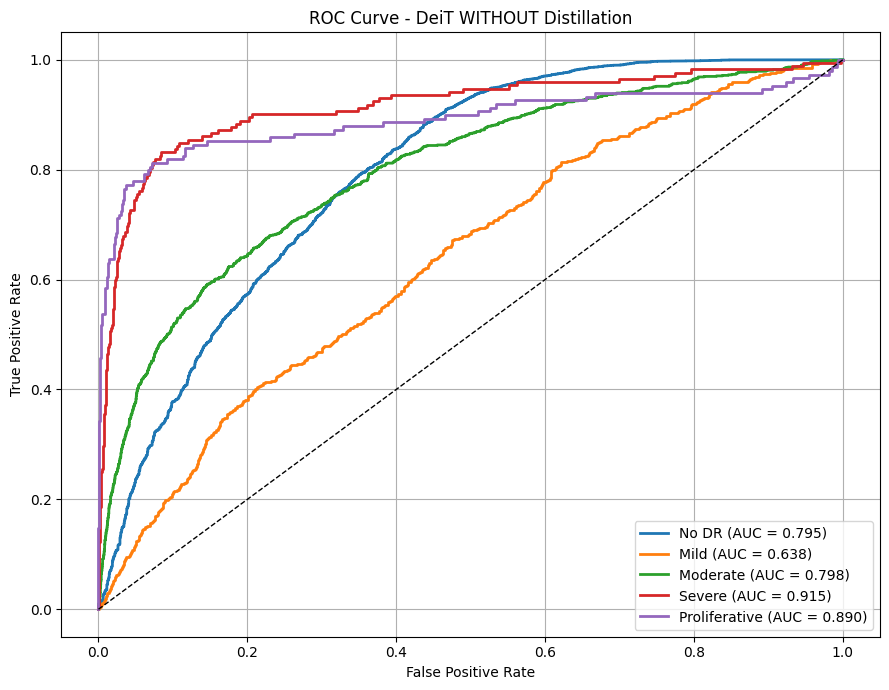

Saved ROC curve: SplitDATA/logs/roc_curves/roc_without_distillation.png


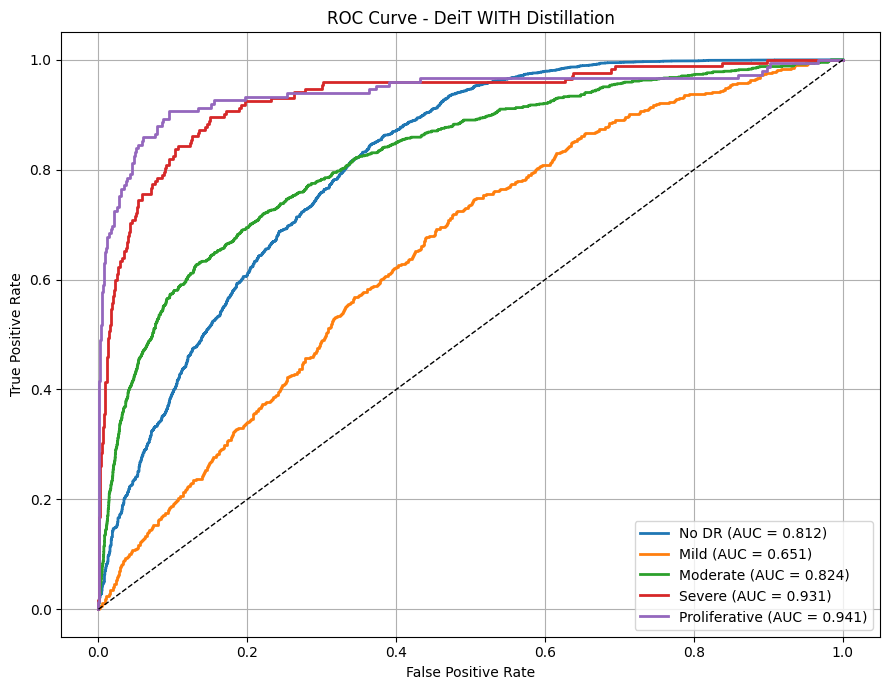

Saved ROC curve: SplitDATA/logs/roc_curves/roc_with_distillation.png


In [ ]:


import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

os.makedirs("SplitDATA/logs/roc_curves", exist_ok=True)

def plot_multiclass_roc(
    test_labels,
    test_probs,
    class_names,
    title,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0,1,2,3,4]
    )

    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(9, 7))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        )

    # random baseline
    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Saved ROC curve: {save_path}")



plot_multiclass_roc(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_without_distillation.png"
)



plot_multiclass_roc(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITH Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_with_distillation.png"
)

In [ ]:


from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from IPython.display import display
import pandas as pd
import numpy as np
import os

os.makedirs("SplitDATA/logs", exist_ok=True)


def compute_map(
    test_labels,
    test_probs,
    class_names,
    model_name,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0, 1, 2, 3, 4]
    )

    n_classes = y_true_bin.shape[1]

    ap_per_class = []

    result_text = (
        f"====================================================\n"
        f"mAP RESULTS - {model_name}\n"
        f"====================================================\n\n"
    )

    print(f"\n{model_name}")

    for i in range(n_classes):

        ap = average_precision_score(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        ap_per_class.append(ap)

        result_text += f"{class_names[i]} AP: {ap:.4f}\n"

        print(f"{class_names[i]} AP: {ap:.4f}")

    mAP = np.mean(ap_per_class)

    result_text += f"\nmAP: {mAP:.4f}\n"

    print(f"\nmAP: {mAP:.4f}")

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved mAP results to: {save_path}")

    return {
        "ap_per_class": ap_per_class,
        "mAP": mAP
    }



baseline_map_results = compute_map(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    model_name="DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/map_without_distillation.txt"
)




distilled_map_results = compute_map(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    model_name="DeiT WITH Distillation",
    save_path="SplitDATA/logs/map_with_distillation.txt"
)



map_summary_path = "SplitDATA/logs/map_comparison_summary.txt"

summary_text = (
    "====================================================\n"
    "FINAL mAP COMPARISON\n"
    "====================================================\n\n"
    "DeiT WITHOUT Distillation\n"
    f"mAP: {baseline_map_results['mAP']:.4f}\n\n"
    "DeiT WITH Distillation\n"
    f"mAP: {distilled_map_results['mAP']:.4f}\n"
)

print(summary_text)

with open(map_summary_path, "w") as f:
    f.write(summary_text)

print(f"Saved mAP comparison summary to: {map_summary_path}")


comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "QWK",
        "MCC",
        "ROC-AUC OvR",
        "mAP"
    ],

    "DeiT WITHOUT Distillation": [
        baseline_results["accuracy"],
        baseline_results["balanced_accuracy"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"],
        baseline_results["weighted_f1"],
        baseline_results["qwk"],
        baseline_results["mcc"],
        baseline_results["auc"] if baseline_results["auc"] is not None else np.nan,
        baseline_map_results["mAP"]
    ],

    "DeiT WITH Distillation": [
        distilled_results["accuracy"],
        distilled_results["balanced_accuracy"],
        distilled_results["macro_precision"],
        distilled_results["macro_recall"],
        distilled_results["macro_f1"],
        distilled_results["weighted_f1"],
        distilled_results["qwk"],
        distilled_results["mcc"],
        distilled_results["auc"] if distilled_results["auc"] is not None else np.nan,
        distilled_map_results["mAP"]
    ]
    
    
})


comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print("\nFINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")

display(
    comparison_df.style
    .set_caption("Original Argmax Results: DeiT Without vs With Distillation")
    .set_properties(**{
        "text-align": "center"
    })
)



table_csv_path = "SplitDATA/logs/final_comparison_table_argmax.csv"
table_txt_path = "SplitDATA/logs/final_comparison_table_argmax.txt"

comparison_df.to_csv(table_csv_path, index=False)

with open(table_txt_path, "w") as f:
    f.write("FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS\n")
    f.write("====================================================\n\n")
    f.write(comparison_df.to_string(index=False))

print(f"Saved argmax comparison CSV to: {table_csv_path}")
print(f"Saved argmax comparison TXT to: {table_txt_path}")


DeiT WITHOUT Distillation
No DR AP: 0.8886
Mild AP: 0.1130
Moderate AP: 0.4740
Severe AP: 0.4189
Proliferative AP: 0.6015

mAP: 0.4992
Saved mAP results to: SplitDATA/logs/map_without_distillation.txt

DeiT WITH Distillation
No DR AP: 0.9027
Mild AP: 0.1105
Moderate AP: 0.5166
Severe AP: 0.4554
Proliferative AP: 0.6309

mAP: 0.5232
Saved mAP results to: SplitDATA/logs/map_with_distillation.txt
FINAL mAP COMPARISON

DeiT WITHOUT Distillation
mAP: 0.4992

DeiT WITH Distillation
mAP: 0.5232

Saved mAP comparison summary to: SplitDATA/logs/map_comparison_summary.txt

FINAL MODEL COMPARISON TABLE - ORIGINAL ARGMAX RESULTS



,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Accuracy,0.784400,0.791300
1,Balanced Accuracy,0.444100,0.450900
2,Macro Precision,0.538100,0.559800
3,Macro Recall,0.444100,0.450900
4,Macro F1,0.474800,0.486300
5,Weighted F1,0.743500,0.755400
6,QWK,0.621500,0.650000
7,MCC,0.417700,0.446200
8,ROC-AUC OvR,0.807200,0.831800
9,mAP,0.499200,0.523200


Saved argmax comparison CSV to: SplitDATA/logs/final_comparison_table_argmax.csv
Saved argmax comparison TXT to: SplitDATA/logs/final_comparison_table_argmax.txt
